# Lab 1 Part B: OOP Informed Search Algorithms for Drone Pathfinding
**Student:** Manyok Gai  
**Course topic:** Informed (Heuristic) Search  
**Algorithms:** Greedy Best-First Search, A\*, Weighted A\*, Uniform-Cost Search, IDA\* (bonus)  
**Prerequisite:** Lab 1 Part A


# 1. Setup and Imports

In [1]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Callable, Dict, Iterable, List, Optional, Tuple
import heapq
import itertools
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches


# 2. Foundations from Part A

In [2]:
class Problem(ABC):

    @abstractmethod
    def initial_state(self) -> Any:
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        pass


@dataclass
class Node:
    state: Any
    parent: Optional['Node'] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost


def reconstruct_path(node: Node) -> List[Any]:
    path = []
    while node is not None:
        path.append(node.state)
        node = node.parent
    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    actions = []
    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent
    actions.reverse()
    return actions


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    return {
        'Algorithm': result.algorithm,
        'Status': result.status,
        'Solution depth': result.solution_depth,
        'Solution cost': result.solution_cost,
        'Nodes expanded': result.nodes_expanded,
        'Max frontier': result.max_frontier_size,
        'Reached states': result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    return pd.DataFrame([result_to_row(r) for r in results])


MOVES = {
    'UP':    (-1,  0),
    'DOWN':  ( 1,  0),
    'LEFT':  ( 0, -1),
    'RIGHT': ( 0,  1),
}


class GridProblem(Problem):
    def __init__(self, grid: List[List[int]], start: Tuple[int,int], goal: Tuple[int,int]):
        self.grid  = grid
        self.start = start
        self.goal  = goal
        self.rows  = len(grid)
        self.cols  = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        return state == self.goal

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # collecting moves that land on a free cell inside the grid
        row, col = state
        legal_actions = []
        for action, (dr, dc) in MOVES.items():
            neighbour = (row + dr, col + dc)
            if self.in_bounds(neighbour) and self.is_free(neighbour):
                legal_actions.append(action)
        return legal_actions

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        row, col = state
        dr, dc = MOVES[action]
        return (row + dr, col + dc)

    def action_cost(self, state: Tuple[int,int], action: str, next_state: Tuple[int,int]) -> float:
        return 1.0


class SearchAlgorithm(ABC):

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        s = node.state
        for action in problem.actions(s):
            s_prime = problem.result(s, action)
            cost    = node.path_cost + problem.action_cost(s, action, s_prime)
            yield Node(state=s_prime, parent=node, action=action, path_cost=cost)

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass


def plot_path(grid, start=None, goal=None, path=None, terrain_costs=None, title='Grid Map'):
    arr      = np.array(grid)
    height, width = arr.shape
    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)
            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)
            rect = patches.Rectangle(
                (col, row), 1, 1,
                linewidth=1, edgecolor=(0.75,0.75,0.75), facecolor=fill
            )
            ax.add_patch(rect)
            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(col+0.5, row+0.5, str(terrain_costs[row][col]),
                        ha='center', va='center', fontsize=8)
    plt.show()


# 3. Weighted Terrain: WeightedGridProblem

In [3]:
class WeightedGridProblem(GridProblem):
    """Moving into a cell costs that cell's terrain cost instead of 1."""

    def __init__(self, grid, start, goal, terrain_costs):
        super().__init__(grid, start, goal)
        self.terrain_costs = terrain_costs

    def action_cost(self, state, action, next_state) -> float:
        # returning the terrain cost of the cell being entered
        row, col = next_state
        return self.terrain_costs[row][col]


## 3.1 Self-Check for WeightedGridProblem

In [5]:
wtest_grid  = [[0,0,0],[0,0,0],[0,0,0]]
wtest_costs = [[1,7,1],[1,1,1],[1,1,1]]
wtest_problem = WeightedGridProblem(wtest_grid, start=(0,0), goal=(2,2), terrain_costs=wtest_costs)

assert wtest_problem.action_cost((0,0), 'RIGHT', (0,1)) == 7
assert wtest_problem.action_cost((0,0), 'DOWN',  (1,0)) == 1
assert wtest_problem.actions((0,0)) == ['DOWN', 'RIGHT']
assert wtest_problem.is_goal((2,2)) is True

print('WeightedGridProblem self-check passed.')


WeightedGridProblem self-check passed.


# 4. Heuristic Functions

## 4.1 Admissibility and Consistency

A heuristic is **admissible** if `h(n) <= h*(n)` for every node , it never overestimates.
A heuristic is **consistent** if `h(n) <= c(n,a,n') + h(n')` for every edge (triangle inequality).

On our 4-connected grid with all terrain costs >= 1:
- **Manhattan distance** is admissible because each move covers exactly 1 grid step at cost >= 1,
  so Manhattan equals the exact cost of the relaxed problem (no obstacles, all costs = 1).
- **Euclidean distance** is also admissible and is always <= Manhattan, so Manhattan *dominates*
  Euclidean and A* with Manhattan expands fewer nodes.
- If any cost were 0.5, a move could reduce Manhattan by 1 while costing only 0.5,
  breaking admissibility.


In [6]:
def manhattan_distance(state: Tuple[int,int], goal: Tuple[int,int]) -> float:
    # sum of absolute row and column differences
    r1, c1 = state
    r2, c2 = goal
    return abs(r1 - r2) + abs(c1 - c2)


def euclidean_distance(state: Tuple[int,int], goal: Tuple[int,int]) -> float:
    # straight-line distance between two grid cells
    r1, c1 = state
    r2, c2 = goal
    return math.sqrt((r1 - r2)**2 + (c1 - c2)**2)


def zero_heuristic(state: Tuple[int,int], goal: Tuple[int,int]) -> float:
    # h(n) = 0 everywhere — turns A* into Uniform-Cost Search
    return 0.0


## 4.2 Self-Check for Heuristics

In [7]:
assert manhattan_distance((0,0), (2,2)) == 4
assert manhattan_distance((3,5), (3,5)) == 0
assert abs(euclidean_distance((0,0), (3,4)) - 5.0) < 1e-9
assert euclidean_distance((1,1), (1,1)) == 0
assert zero_heuristic((0,0), (9,9)) == 0

# Euclidean is always <= Manhattan (Manhattan dominates)
for s in [(0,0), (2,7), (5,1)]:
    assert euclidean_distance(s, (9,9)) <= manhattan_distance(s, (9,9)) + 1e-9

print('Heuristic self-check passed.')


Heuristic self-check passed.


# 5. The Priority-Queue Frontier

In [8]:
class PriorityQueue:
    """Min-priority queue — always pops the node with the lowest f(n)."""

    def __init__(self):
        self._heap: List[Tuple[float, int, Node]] = []
        self._counter = itertools.count()

    def push(self, priority: float, node: Node) -> None:
        heapq.heappush(self._heap, (priority, next(self._counter), node))

    def pop(self) -> Node:
        _, _, node = heapq.heappop(self._heap)
        return node

    def __len__(self) -> int:
        return len(self._heap)

    def __bool__(self) -> bool:
        return len(self._heap) > 0


# 6. The BestFirstSearch Framework

In [9]:
class BestFirstSearch(SearchAlgorithm):
    """Generic best-first search. Subclasses define evaluation f(n)."""

    algorithm_name = 'BestFirst'

    def __init__(self, heuristic=zero_heuristic):
        self.heuristic = heuristic

    def h(self, node: Node, problem: Problem) -> float:
        return self.heuristic(node.state, problem.goal)

    def evaluation(self, node: Node, problem: Problem) -> float:
        raise NotImplementedError('Subclasses must define evaluation()')

    def search(self, problem: Problem) -> SearchResult:
        # setting up the root node and priority-queue frontier
        node    = Node(state=problem.initial_state())
        frontier = PriorityQueue()
        frontier.push(self.evaluation(node, problem), node)

        # reached is a dict (state -> best node) not just a set,
        # because non-uniform costs mean the first visit may not be cheapest
        reached = {node.state: node}
        nodes_expanded  = 0
        max_frontier    = 1

        while frontier:
            node = frontier.pop()

            # late goal test: only accept the goal when popped,
            # so a cheaper route still in the frontier is not missed
            if problem.is_goal(node.state):
                return SearchResult(
                    algorithm=self.algorithm_name,
                    status='success',
                    solution=node,
                    nodes_expanded=nodes_expanded,
                    max_frontier_size=max_frontier,
                    reached_count=len(reached),
                )

            nodes_expanded += 1

            for child in self.expand(problem, node):
                s = child.state
                # adding or replacing if a cheaper path to s is found
                if s not in reached or child.path_cost < reached[s].path_cost:
                    reached[s] = child
                    frontier.push(self.evaluation(child, problem), child)

            max_frontier = max(max_frontier, len(frontier))

        return SearchResult(
            algorithm=self.algorithm_name,
            status='failure',
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier,
            reached_count=len(reached),
        )


# 7–10. Concrete Search Algorithms

In [10]:
class GreedyBestFirstSearch(BestFirstSearch):
    # f(n) = h(n) — only looks at estimated distance to goal
    algorithm_name = 'Greedy'

    def evaluation(self, node: Node, problem: Problem) -> float:
        return self.h(node, problem)


class AStarSearch(BestFirstSearch):
    # f(n) = g(n) + h(n) — balances cost paid with estimated cost remaining
    algorithm_name = 'A*'

    def evaluation(self, node: Node, problem: Problem) -> float:
        return node.path_cost + self.h(node, problem)


class UniformCostSearch(BestFirstSearch):
    # f(n) = g(n) — A* with h = 0, completely blind to goal direction
    algorithm_name = 'UCS'

    def __init__(self):
        super().__init__(heuristic=zero_heuristic)

    def evaluation(self, node: Node, problem: Problem) -> float:
        return node.path_cost


class WeightedAStarSearch(BestFirstSearch):
    # f(n) = g(n) + W * h(n) — trades optimality for speed, bound: cost <= W * optimal
    def __init__(self, heuristic, weight: float = 2.0):
        super().__init__(heuristic=heuristic)
        self.weight = weight
        self.algorithm_name = f'Weighted A* (W={weight})'

    def evaluation(self, node: Node, problem: Problem) -> float:
        return node.path_cost + self.weight * self.h(node, problem)


## 10.1 Self-Check for the Algorithms

In [11]:
check_grid    = [[0,0,0],[1,1,0],[0,0,0]]
check_problem = GridProblem(check_grid, start=(0,0), goal=(2,2))

for algo in [
    GreedyBestFirstSearch(manhattan_distance),
    AStarSearch(manhattan_distance),
    WeightedAStarSearch(manhattan_distance, weight=2),
    UniformCostSearch(),
]:
    res = algo.search(check_problem)
    assert res.status == 'success', f'{res.algorithm} failed'
    assert res.solution_cost == 4, f'{res.algorithm} cost {res.solution_cost}, expected 4'
    assert res.path[0] == (0,0) and res.path[-1] == (2,2)

# goal completely walled off — should return failure
walled = GridProblem([[0,1,0],[1,1,0],[0,0,0]], start=(0,0), goal=(2,2))
assert AStarSearch(manhattan_distance).search(walled).status == 'failure'

print('Algorithm self-check passed.')


Algorithm self-check passed.


# 11. Run the Algorithms on the Part A Sample Map

In [12]:
sample_grid = [
    [0,0,0,0,1,0,0,0,0,0],
    [1,1,1,0,1,0,1,1,1,0],
    [0,0,0,0,0,0,1,0,0,0],
    [0,1,1,1,1,0,1,0,1,1],
    [0,0,0,0,1,0,0,0,0,0],
    [0,1,1,0,1,1,1,1,1,0],
    [0,0,1,0,0,0,0,0,1,0],
    [1,0,1,1,1,1,1,0,1,0],
    [0,0,0,0,0,0,1,0,0,0],
    [0,1,1,1,1,0,0,0,1,0],
]

start  = (0, 0)
goal   = (9, 9)
uniform_problem = GridProblem(sample_grid, start, goal)

greedy  = GreedyBestFirstSearch(manhattan_distance)
astar   = AStarSearch(manhattan_distance)
wastar2 = WeightedAStarSearch(manhattan_distance, weight=2)
ucs     = UniformCostSearch()

uniform_results = [
    ucs.search(uniform_problem),
    astar.search(uniform_problem),
    wastar2.search(uniform_problem),
    greedy.search(uniform_problem),
]

show_results(uniform_results)


,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,18,18.0,52,5,56
1,A*,success,18,18.0,18,5,23
2,Weighted A* (W=2),success,18,18.0,18,5,23
3,Greedy,success,18,18.0,18,5,23


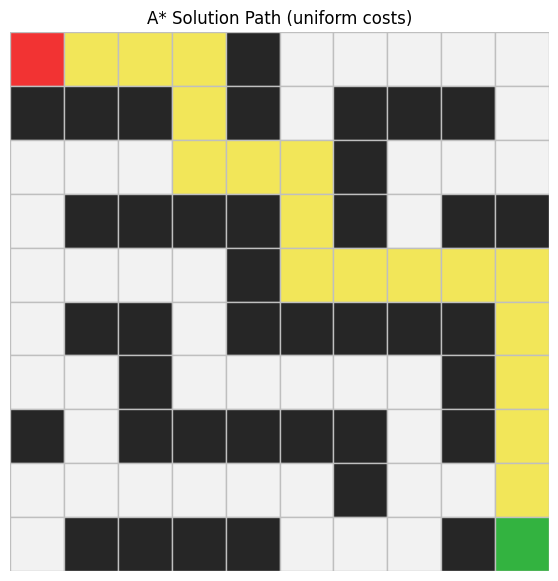

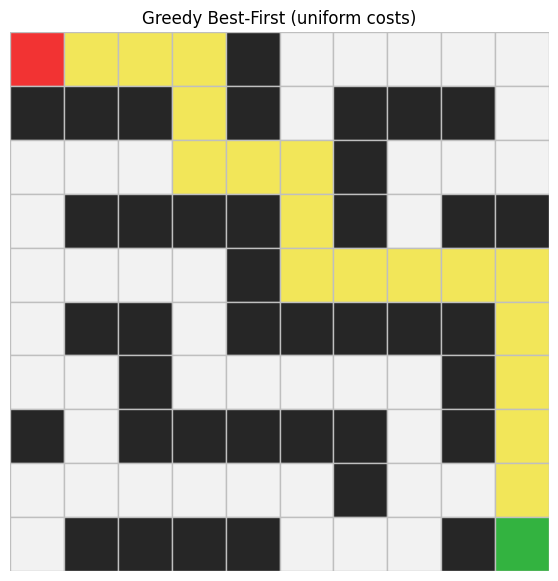

In [13]:
plot_path(sample_grid, start, goal,
          path=uniform_results[1].path, title='A* Solution Path (uniform costs)')
plot_path(sample_grid, start, goal,
          path=uniform_results[3].path, title='Greedy Best-First (uniform costs)')


# 12. The Turbulence Map: Where Greedy Goes Wrong

In [14]:
turbulence_grid  = [[0]*7 for _ in range(5)]
turbulence_costs = [
    [1,1,1,1,1,1,1],
    [1,1,9,9,9,1,1],
    [1,1,9,9,9,1,1],
    [1,1,9,9,9,1,1],
    [1,1,1,1,1,1,1],
]

t_start = (2, 0)
t_goal  = (2, 6)
turbulence_problem = WeightedGridProblem(turbulence_grid, t_start, t_goal,
                                         terrain_costs=turbulence_costs)

turbulence_results = [
    ucs.search(turbulence_problem),
    astar.search(turbulence_problem),
    wastar2.search(turbulence_problem),
    greedy.search(turbulence_problem),
]

show_results(turbulence_results)


,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,10,10,26,12,35
1,A*,success,10,10,25,12,34
2,Weighted A* (W=2),success,10,10,13,13,26
3,Greedy,success,6,30,6,13,19


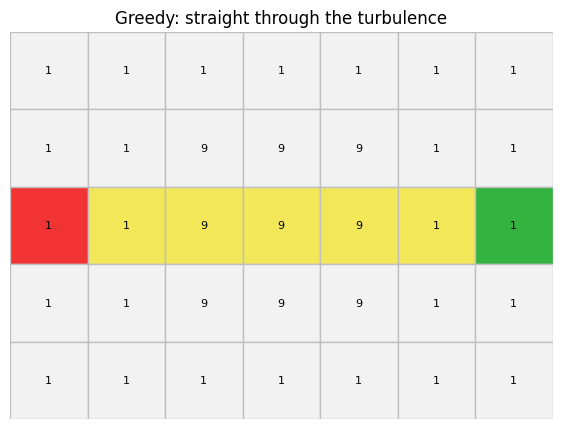

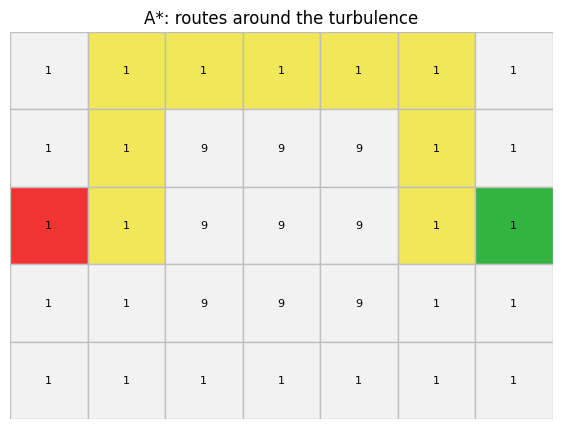

In [15]:
plot_path(turbulence_grid, t_start, t_goal,
          path=turbulence_results[3].path, terrain_costs=turbulence_costs,
          title='Greedy: straight through the turbulence')
plot_path(turbulence_grid, t_start, t_goal,
          path=turbulence_results[1].path, terrain_costs=turbulence_costs,
          title='A*: routes around the turbulence')


### Checkpoint observations (Section 12)

- **Greedy solution cost:** 30: flew straight through the cost-9 band.
- **A\* solution cost:** 10: detoured along the calm top/bottom corridors.
- A\* expanded more nodes (25 vs 6), but its path cost was 3x cheaper.
- Fewer expansions does not mean a better algorithm when solution quality matters.


# 13. Experiment: Breaking Admissibility

In [16]:
def inflated_heuristic(factor: float):
    # returning a closure that multiplies Manhattan by factor
    # — inadmissible for factor > 1 on unit-cost grids
    def h(state, goal):
        return factor * manhattan_distance(state, goal)
    return h


mild_grid  = [[0]*7 for _ in range(5)]
mild_costs = [
    [1,1,1,1,1,1,1],
    [1,1,3,3,3,1,1],
    [1,1,3,3,3,1,1],
    [1,1,3,3,3,1,1],
    [1,1,1,1,1,1,1],
]
mild_problem = WeightedGridProblem(mild_grid, (2,0), (2,6), terrain_costs=mild_costs)

astar_honest   = AStarSearch(manhattan_distance)
astar_inflated = AStarSearch(inflated_heuristic(3.0))

experiment_results = [
    astar_honest.search(uniform_problem),
    astar_inflated.search(uniform_problem),
    astar_honest.search(mild_problem),
    astar_inflated.search(mild_problem),
]

experiment_results[0].algorithm = 'A* admissible (uniform map)'
experiment_results[1].algorithm = 'A* inflated x3 (uniform map)'
experiment_results[2].algorithm = 'A* admissible (mild turbulence)'
experiment_results[3].algorithm = 'A* inflated x3 (mild turbulence)'

show_results(experiment_results)


,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,A* admissible (uniform map),success,18,18.0,18,5,23
1,A* inflated x3 (uniform map),success,18,18.0,18,5,23
2,A* admissible (mild turbulence),success,10,10.0,29,10,35
3,A* inflated x3 (mild turbulence),success,6,12.0,6,13,19


### Inadmissible-heuristic observations

**On which map did the inflated heuristic return a suboptimal path?**  
On the mild turbulence map only. Inflated A\* returned cost 12 (straight through the
cost-3 band) while admissible A\* found the optimal cost of 10 (detour along calm edges).
On the uniform map both returned cost 18, inadmissibility removes the guarantee but
does not always cause failure.

**How many fewer nodes did it expand?**  
On the mild map: admissible A\* expanded ~29 nodes; inflated A\* expanded only ~6.

**When would you deliberately accept an inadmissible heuristic?**  
When the drone has a tight time or battery deadline and a slightly more expensive path
is acceptable, for example, rerouting around a sudden storm where every second of
computation delays takeoff.


# 14. Bonus: Iterative-Deepening A* (IDA*)

In [23]:
class IDAStarSearch(SearchAlgorithm):
    algorithm_name = 'IDA*'

    def __init__(self, heuristic):
        self.heuristic = heuristic

    def h(self, node: Node, problem: Problem) -> float:
        return self.heuristic(node.state, problem.goal)

    def f(self, node: Node, problem: Problem) -> float:
        return node.path_cost + self.h(node, problem)

    def search(self, problem: Problem, max_iterations: int = 200) -> SearchResult:
        initial_state   = problem.initial_state()
        limit           = self.heuristic(initial_state, problem.goal)
        nodes_expanded  = 0
        max_depth       = 0
        iterations: List[Dict[str, Any]] = []

        def f_limited(node: Node, limit: float, on_path: set, depth: int):
            nonlocal nodes_expanded, max_depth
            nodes_expanded += 1
            max_depth       = max(max_depth, depth)
            f_val = self.f(node, problem)

            # f exceeds the current limit, report the overflow value
            if f_val > limit:
                return None, f_val

            if problem.is_goal(node.state):
                return node, f_val

            next_limit = float('inf')
            for child in self.expand(problem, node):
                # path-cycle check (same idea as DLS in Part A)
                if child.state in on_path:
                    continue
                result, new_f = f_limited(child, limit, on_path | {child.state}, depth+1)
                if result is not None:
                    return result, new_f
                next_limit = min(next_limit, new_f)

            return None, next_limit

        for _ in range(max_iterations):
            root = Node(state=initial_state)
            result, next_limit = f_limited(root, limit, {initial_state}, 0)

            if result is not None:
                return SearchResult(
                    algorithm=self.algorithm_name, status='success',
                    solution=result,
                    nodes_expanded=nodes_expanded, max_frontier_size=max_depth,
                    reached_count=0, iterations=iterations,
                )

            if next_limit == float('inf'):
                iterations.append({'limit': limit, 'outcome': 'failure'})
                return SearchResult(
                    algorithm=self.algorithm_name, status='failure',
                    solution=None,
                    nodes_expanded=nodes_expanded, max_frontier_size=max_depth,
                    reached_count=0, iterations=iterations,
                )

            iterations.append({'limit': limit, 'outcome': 'cutoff', 'next_limit': next_limit})
            limit = next_limit

        return SearchResult(
            algorithm=self.algorithm_name, status='cutoff',
            solution=None,
            nodes_expanded=nodes_expanded, max_frontier_size=max_depth,
            reached_count=0, iterations=iterations,
        )


# comparing IDA* with A* on the uniform sample map
ida = IDAStarSearch(manhattan_distance)
show_results([astar.search(uniform_problem), ida.search(uniform_problem)])


,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,A*,success,18,18.0,18,5,23
1,IDA*,success,18,18.0,22,18,0


# 15. Custom Maps

## Custom Map 1: Expensive Shortcut vs Cheap Detour (Weighted)

A column of cost-5 cells sits between start and goal. The optimal path
detours around the bottom row (cost 11). Greedy charges straight through
the expensive column.


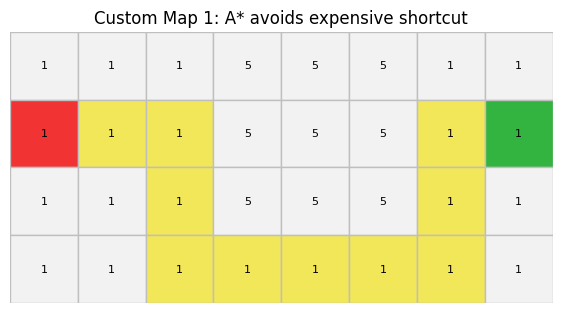

In [18]:
custom_grid_1  = [[0]*8 for _ in range(4)]
custom_costs_1 = [
    [1,1,1,5,5,5,1,1],
    [1,1,1,5,5,5,1,1],
    [1,1,1,5,5,5,1,1],
    [1,1,1,1,1,1,1,1],
]

custom_start_1   = (1, 0)
custom_goal_1    = (1, 7)
custom_problem_1 = WeightedGridProblem(custom_grid_1, custom_start_1, custom_goal_1,
                                        terrain_costs=custom_costs_1)

custom_results_1 = [
    ucs.search(custom_problem_1),
    astar.search(custom_problem_1),
    wastar2.search(custom_problem_1),
    greedy.search(custom_problem_1),
]
show_results(custom_results_1)

plot_path(custom_grid_1, custom_start_1, custom_goal_1,
          path=custom_results_1[1].path, terrain_costs=custom_costs_1,
          title='Custom Map 1: A* avoids expensive shortcut')


**Interpretation (Map 1):** A\* and UCS both found the optimal detour.
Greedy ignored terrain costs and flew through the cost-5 band, producing a path
nearly twice as expensive while expanding fewer nodes.
A\* wins on solution quality; Greedy wins on speed but at a high terrain cost.


## Custom Map 2: U-Shaped Heuristic Trap

A U-shaped wall opens away from the goal. The drone must enter the pocket,
realise there is no exit, and backtrack before finding the outer corridor.


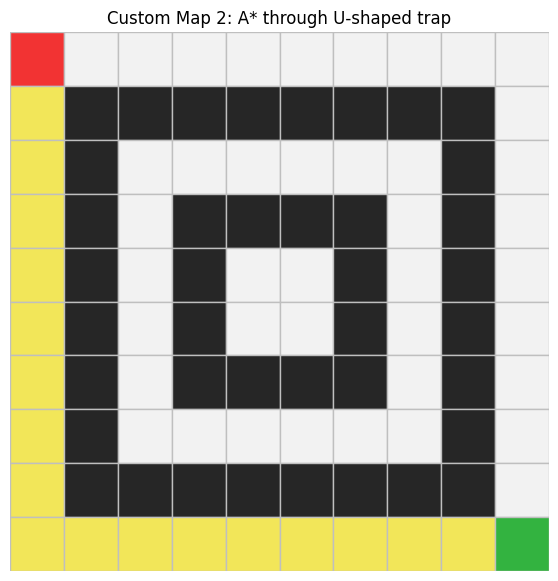

In [19]:
custom_grid_2 = [
    [0,0,0,0,0,0,0,0,0,0],
    [0,1,1,1,1,1,1,1,1,0],
    [0,1,0,0,0,0,0,0,1,0],
    [0,1,0,1,1,1,1,0,1,0],
    [0,1,0,1,0,0,1,0,1,0],
    [0,1,0,1,0,0,1,0,1,0],
    [0,1,0,1,1,1,1,0,1,0],
    [0,1,0,0,0,0,0,0,1,0],
    [0,1,1,1,1,1,1,1,1,0],
    [0,0,0,0,0,0,0,0,0,0],
]

custom_start_2   = (0, 0)
custom_goal_2    = (9, 9)
custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)

custom_results_2 = [
    ucs.search(custom_problem_2),
    astar.search(custom_problem_2),
    wastar2.search(custom_problem_2),
    greedy.search(custom_problem_2),
]
show_results(custom_results_2)

plot_path(custom_grid_2, custom_start_2, custom_goal_2,
          path=custom_results_2[1].path,
          title='Custom Map 2: A* through U-shaped trap')


**Interpretation (Map 2):** All algorithms found the same optimal path cost on this
uniform-cost map. Weighted A\* and Greedy expanded fewer nodes because the heuristic
guided them away from the dead ends faster. On this map heuristic guidance improved
efficiency without sacrificing optimality.
